In [1]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================
# This cell imports all required Python libraries for data loading,
# cleaning, preprocessing, encoding, scaling, and train-test splitting.
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# CELL 2: LOAD DATASET
# ============================================================
# This cell loads the paddy dataset from CSV format.
# Make sure the file name is correct and the CSV file is in the
# same folder as this notebook.
# ============================================================

df = pd.read_csv("paddydataset.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Dataset shape: (2789, 45)


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [3]:
# ============================================================
# CELL 3: CLEAN COLUMN NAMES
# ============================================================
# Some column names may contain extra spaces.
# Example: 'Hectares ' has an extra space at the end.
# This cell removes unwanted spaces and makes column names cleaner.
# ============================================================

df.columns = df.columns.str.strip()

print("Column names cleaned successfully.")
print("Total columns:", len(df.columns))

print("\nColumn names:")
for col in df.columns:
    print("-", col)

Column names cleaned successfully.
Total columns: 45

Column names:
- Hectares
- Agriblock
- Variety
- Soil Types
- Seedrate(in Kg)
- LP_Mainfield(in Tonnes)
- Nursery
- Nursery area (Cents)
- LP_nurseryarea(in Tonnes)
- DAP_20days
- Weed28D_thiobencarb
- Urea_40Days
- Potassh_50Days
- Micronutrients_70Days
- Pest_60Day(in ml)
- 30DRain( in mm)
- 30DAI(in mm)
- 30_50DRain( in mm)
- 30_50DAI(in mm)
- 51_70DRain(in mm)
- 51_70AI(in mm)
- 71_105DRain(in mm)
- 71_105DAI(in mm)
- Min temp_D1_D30
- Max temp_D1_D30
- Min temp_D31_D60
- Max temp_D31_D60
- Min temp_D61_D90
- Max temp_D61_D90
- Min temp_D91_D120
- Max temp_D91_D120
- Inst Wind Speed_D1_D30(in Knots)
- Inst Wind Speed_D31_D60(in Knots)
- Inst Wind Speed_D61_D90(in Knots)
- Inst Wind Speed_D91_D120(in Knots)
- Wind Direction_D1_D30
- Wind Direction_D31_D60
- Wind Direction_D61_D90
- Wind Direction_D91_D120
- Relative Humidity_D1_D30
- Relative Humidity_D31_D60
- Relative Humidity_D61_D90
- Relative Humidity_D91_D120
- Trash(in bun

In [4]:
# ============================================================
# CELL 4: BASIC DATASET INFORMATION
# ============================================================
# This cell checks:
# 1. Number of rows and columns
# 2. Data types
# 3. Memory usage
# 4. General structure of the dataset
# ============================================================

print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (2789, 45)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   object 
 2   Variety                             2789 non-null   object 
 3   Soil Types                          2789 non-null   object 
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   object 
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [5]:
# ============================================================
# CELL 5: CHECK MISSING VALUES
# ============================================================
# Missing values can affect machine learning models.
# This cell checks whether any column contains missing values.
# ============================================================

missing_values = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

print("Missing value summary:")
display(missing_summary)

print("\nTotal missing values in dataset:", df.isnull().sum().sum())

Missing value summary:


,Missing Values,Missing Percentage
Hectares,0,0.0
Agriblock,0,0.0
Variety,0,0.0
Soil Types,0,0.0
Seedrate(in Kg),0,0.0
LP_Mainfield(in Tonnes),0,0.0
Nursery,0,0.0
Nursery area (Cents),0,0.0
LP_nurseryarea(in Tonnes),0,0.0
DAP_20days,0,0.0



Total missing values in dataset: 0


In [6]:
# ============================================================
# CELL 6: CHECK AND REMOVE DUPLICATES
# ============================================================
# Duplicate rows may cause data leakage and biased model performance.
# This cell checks exact duplicate rows and removes them.
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows before removal:", duplicate_count)
print("Dataset shape before duplicate removal:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("\nDuplicate rows removed successfully.")
print("Number of duplicate rows after removal:", df.duplicated().sum())
print("Dataset shape after duplicate removal:", df.shape)

Number of duplicate rows before removal: 451
Dataset shape before duplicate removal: (2789, 45)

Duplicate rows removed successfully.
Number of duplicate rows after removal: 0
Dataset shape after duplicate removal: (2338, 45)


In [7]:
# ============================================================
# CELL 7: CLEAN CATEGORICAL VALUES
# ============================================================
# Categorical columns may contain unwanted spaces or inconsistent
# text formatting. This cell cleans all text columns.
# ============================================================

categorical_cols_initial = df.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns found:")
print(categorical_cols_initial)

for col in categorical_cols_initial:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("\nCategorical text values cleaned successfully.")

print("\nSample unique values from categorical columns:")
for col in categorical_cols_initial:
    print(f"\n{col}:")
    print(df[col].unique()[:10])

Categorical columns found:
['Agriblock', 'Variety', 'Soil Types', 'Nursery', 'Wind Direction_D1_D30', 'Wind Direction_D31_D60', 'Wind Direction_D61_D90', 'Wind Direction_D91_D120']

Categorical text values cleaned successfully.

Sample unique values from categorical columns:

Agriblock:
['cuddalore' 'kurinjipadi' 'panruti' 'kallakurichi' 'sankarapuram'
 'chinnasalem']

Variety:
['co_43' 'ponmani' 'delux ponni']

Soil Types:
['alluvial' 'clay']

Nursery:
['dry' 'wet']

Wind Direction_D1_D30:
['sw' 'nw' 'ene' 'w' 'sse' 'e']

Wind Direction_D31_D60:
['w' 's' 'ne' 'wnw' 'ene']

Wind Direction_D61_D90:
['nnw' 'se' 'nne' 'sw' 'ne']

Wind Direction_D91_D120:
['wsw' 'sse' 'w' 's' 'nw' 'nnw']


In [8]:
# ============================================================
# CELL 8: CREATE YIELD PER HECTARE FEATURE
# ============================================================
# Total paddy yield is strongly affected by land size.
# Therefore, yield per hectare is created to measure productivity.
#
# Formula:
# Yield per hectare = Paddy yield / Hectares
# ============================================================

df["Yield_per_hectare"] = df["Paddy yield(in Kg)"] / df["Hectares"]

print("New feature created: Yield_per_hectare")

display(df[["Hectares", "Paddy yield(in Kg)", "Yield_per_hectare"]].head())

print("\nYield per hectare summary:")
display(df["Yield_per_hectare"].describe())

New feature created: Yield_per_hectare


,Hectares,Paddy yield(in Kg),Yield_per_hectare
0,6,35028,5838.0
1,6,35412,5902.0
2,6,36300,6050.0
3,6,35016,5836.0
4,6,34044,5674.0



Yield per hectare summary:


,Yield_per_hectare
count,2338.000000
mean,5985.004277
std,289.352651
min,5410.000000
25%,5780.000000
50%,5964.000000
75%,6227.000000
max,6469.000000


In [9]:
# ============================================================
# CELL 9: DEFINE TARGET AND INPUT FEATURES
# ============================================================
# In this project, the target variable is fixed as:
#
# Yield_per_hectare
#
# This target represents paddy productivity per hectare instead
# of total paddy production.
#
# Since Yield_per_hectare was calculated from:
# Paddy yield(in Kg) / Hectares
#
# The original total yield column must be removed from input
# features to avoid direct leakage.
# ============================================================

TARGET_COLUMN = "Yield_per_hectare"

# Columns to remove from input features
drop_columns = [
    TARGET_COLUMN,          # remove target column from X
    "Paddy yield(in Kg)"    # remove original yield because it was used to create target
]

# Create input features and target variable
X = df.drop(columns=drop_columns)
y = df[TARGET_COLUMN]

print("Target column selected:", TARGET_COLUMN)
print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nColumns removed from input features:")
print(drop_columns)

print("\nInput feature preview:")
display(X.head())

print("\nTarget preview:")
display(y.head())

Target column selected: Yield_per_hectare
Input feature shape: (2338, 44)
Target shape: (2338,)

Columns removed from input features:
['Yield_per_hectare', 'Paddy yield(in Kg)']

Input feature preview:


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Inst Wind Speed_D91_D120(in Knots),Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles)
0,6,cuddalore,co_43,alluvial,150,75.0,dry,120,6,240,...,10,sw,w,nnw,wsw,72.0,78,88,85,540
1,6,kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,6,nw,s,se,sse,64.6,85,84,87,600
2,6,panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,12,ene,ne,nne,w,85.0,96,84,79,600
3,6,kallakurichi,co_43,clay,150,75.0,wet,120,6,240,...,6,w,wnw,se,s,88.5,95,81,84,540
4,6,sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,12,sse,w,sw,nw,72.7,91,83,81,600



Target preview:


,Yield_per_hectare
0,5838.0
1,5902.0
2,6050.0
3,5836.0
4,5674.0


In [10]:
# ============================================================
# CELL 10: IDENTIFY NUMERIC AND CATEGORICAL FEATURES
# ============================================================
# Machine learning models need numerical input.
# Numeric columns will be scaled.
# Categorical columns will be encoded using OneHotEncoder.
# ============================================================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumeric features:")
for col in numeric_features:
    print("-", col)

print("\nCategorical features:")
for col in categorical_features:
    print("-", col)

Number of numeric features: 36
Number of categorical features: 8

Numeric features:
- Hectares
- Seedrate(in Kg)
- LP_Mainfield(in Tonnes)
- Nursery area (Cents)
- LP_nurseryarea(in Tonnes)
- DAP_20days
- Weed28D_thiobencarb
- Urea_40Days
- Potassh_50Days
- Micronutrients_70Days
- Pest_60Day(in ml)
- 30DRain( in mm)
- 30DAI(in mm)
- 30_50DRain( in mm)
- 30_50DAI(in mm)
- 51_70DRain(in mm)
- 51_70AI(in mm)
- 71_105DRain(in mm)
- 71_105DAI(in mm)
- Min temp_D1_D30
- Max temp_D1_D30
- Min temp_D31_D60
- Max temp_D31_D60
- Min temp_D61_D90
- Max temp_D61_D90
- Min temp_D91_D120
- Max temp_D91_D120
- Inst Wind Speed_D1_D30(in Knots)
- Inst Wind Speed_D31_D60(in Knots)
- Inst Wind Speed_D61_D90(in Knots)
- Inst Wind Speed_D91_D120(in Knots)
- Relative Humidity_D1_D30
- Relative Humidity_D31_D60
- Relative Humidity_D61_D90
- Relative Humidity_D91_D120
- Trash(in bundles)

Categorical features:
- Agriblock
- Variety
- Soil Types
- Nursery
- Wind Direction_D1_D30
- Wind Direction_D31_D60
- Wind

In [11]:
# ============================================================
# CELL 11: TRAIN-TEST SPLIT
# ============================================================
# This cell splits the dataset into training and testing data.
#
# Important:
# The dataset has many repeated feature combinations.
# A normal random split may cause leakage.
# Therefore, GroupShuffleSplit is used to keep similar feature
# combinations together in either train or test.
# ============================================================

# Create group labels using all input feature values
groups = X.astype(str).agg("_".join, axis=1)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, test_index = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

print("Train-test split completed successfully.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTarget summary in training data:")
display(y_train.describe())

print("\nTarget summary in testing data:")
display(y_test.describe())

Train-test split completed successfully.
X_train shape: (1937, 44)
X_test shape: (401, 44)
y_train shape: (1937,)
y_test shape: (401,)

Target summary in training data:


,Yield_per_hectare
count,1937.000000
mean,5994.753743
std,289.317826
min,5410.000000
25%,5836.000000
50%,6015.000000
75%,6227.000000
max,6469.000000



Target summary in testing data:


,Yield_per_hectare
count,401.000000
mean,5937.910224
std,285.215922
min,5410.000000
25%,5723.000000
50%,5883.000000
75%,6192.000000
max,6469.000000


In [12]:
# ============================================================
# CELL 12: PREPROCESSING PIPELINE
# ============================================================
# This cell creates a preprocessing pipeline:
#
# 1. Numeric columns:
#    - StandardScaler is used to scale numerical values.
#
# 2. Categorical columns:
#    - OneHotEncoder is used to convert categories into numeric columns.
#
# The fitted preprocessor will be used later for machine learning models.
# ============================================================

# OneHotEncoder syntax differs slightly across sklearn versions.
# This makes the code work in both old and new versions.
try:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", onehot_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Fit only on training data to avoid data leakage
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully.")
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

print("\nReady for model training:")
print("X_train_processed")
print("X_test_processed")
print("y_train")
print("y_test")
print("preprocessor")

Preprocessing completed successfully.
Processed X_train shape: (1937, 71)
Processed X_test shape: (401, 71)

Ready for model training:
X_train_processed
X_test_processed
y_train
y_test
preprocessor


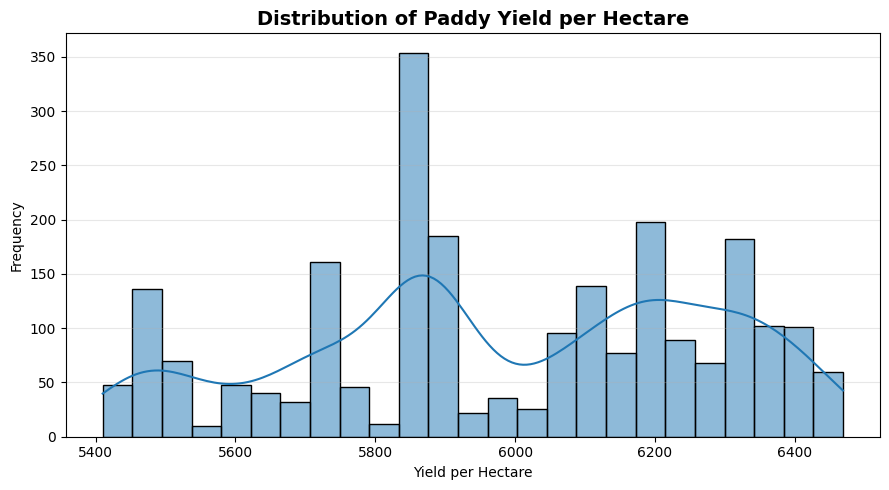

shows how the target variable Yield_per_hectare is distributed.
This helps identify whether productivity values are balanced, skewed, or concentrated.


In [15]:
# ============================================================
# CELL 13: EDA PLOT 1 - TARGET DISTRIBUTION
# ============================================================
# This plot shows the distribution of Yield_per_hectare.
# It helps to understand whether productivity values are spread
# normally or concentrated around a specific range.
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

TARGET_COLUMN = "Yield_per_hectare"

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x=TARGET_COLUMN,
    bins=25,
    kde=True
)

plt.title("Distribution of Paddy Yield per Hectare", fontsize=14, fontweight="bold")
plt.xlabel("Yield per Hectare")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("shows how the target variable Yield_per_hectare is distributed.")
print("This helps identify whether productivity values are balanced, skewed, or concentrated.")

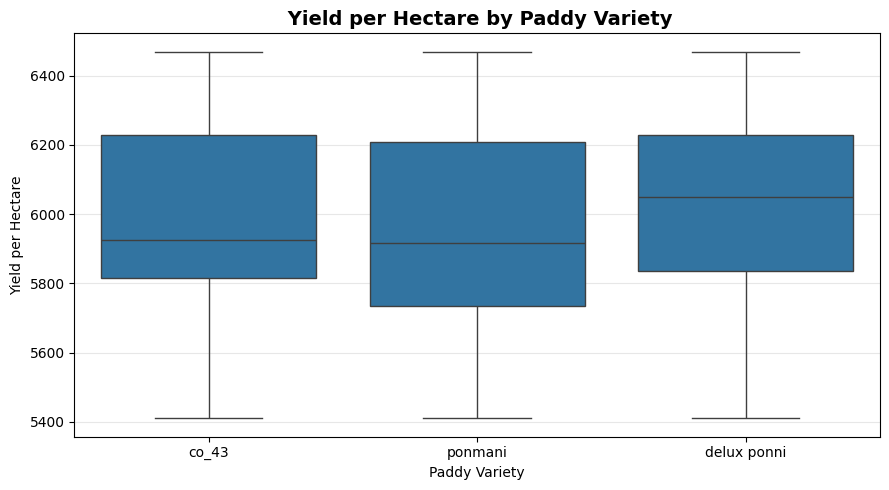

Figure 2 compares productivity among different paddy varieties.
A higher median line indicates better average productivity.


In [17]:
# ============================================================
# CELL 14: EDA PLOT 2 - YIELD PER HECTARE BY VARIETY
# ============================================================
# This boxplot compares paddy productivity across different
# paddy varieties.
# It helps identify which variety has higher or more stable yield.
# ============================================================

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Variety",
    y=TARGET_COLUMN
)

plt.title(" Yield per Hectare by Paddy Variety", fontsize=14, fontweight="bold")
plt.xlabel("Paddy Variety")
plt.ylabel("Yield per Hectare")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure 2 compares productivity among different paddy varieties.")
print("A higher median line indicates better average productivity.")

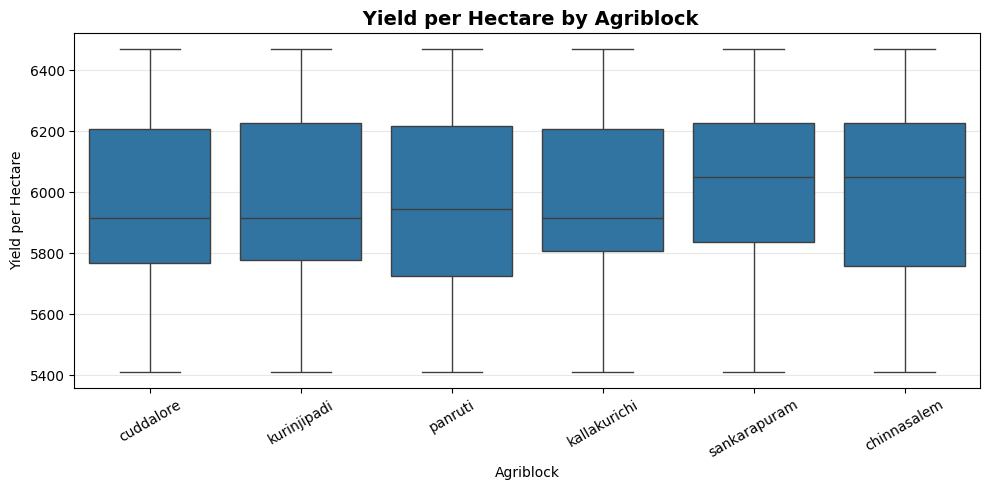

Figure 3 shows productivity differences across agriblocks.
This helps identify whether some regions perform better than others.


In [18]:
# ============================================================
# CELL 15: EDA PLOT 3 - YIELD PER HECTARE BY AGRIBLOCK
# ============================================================
# This plot compares productivity across different agriblocks.
# It helps understand whether location has an effect on yield.
# ============================================================

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Agriblock",
    y=TARGET_COLUMN
)

plt.title(" Yield per Hectare by Agriblock", fontsize=14, fontweight="bold")
plt.xlabel("Agriblock")
plt.ylabel("Yield per Hectare")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure 3 shows productivity differences across agriblocks.")
print("This helps identify whether some regions perform better than others.")

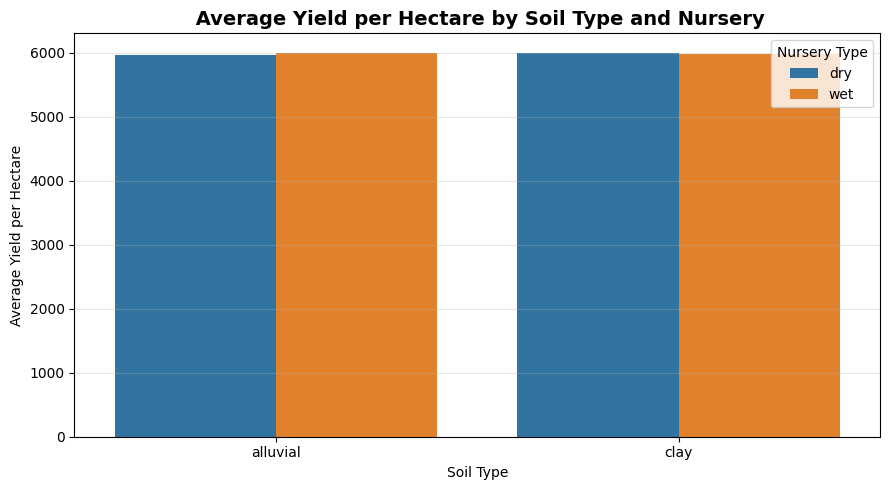

Figure 4 compares average productivity by soil type and nursery method.
This helps check whether wet or dry nursery gives better yield under different soil conditions.


In [19]:
# ============================================================
# CELL 16: EDA PLOT 4 - SOIL TYPE AND NURSERY COMPARISON
# ============================================================
# This plot compares Yield_per_hectare based on Soil Types,
# while also showing Nursery type using hue.
# It helps analyse the combined effect of soil and nursery method.
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Soil Types",
    y=TARGET_COLUMN,
    hue="Nursery",
    errorbar=None
)

plt.title(" Average Yield per Hectare by Soil Type and Nursery", fontsize=14, fontweight="bold")
plt.xlabel("Soil Type")
plt.ylabel("Average Yield per Hectare")
plt.legend(title="Nursery Type")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure 4 compares average productivity by soil type and nursery method.")
print("This helps check whether wet or dry nursery gives better yield under different soil conditions.")

In [21]:
# ============================================================
# CELL 18: IMPORT MODEL AND EVALUATION LIBRARIES
# ============================================================
# Since the target variable is Yield_per_hectare, this is a
# regression problem.
#
# Models used:
# 1. Support Vector Regressor
# 2. Decision Tree Regressor
# 3. XGBoost Regressor
#
# Evaluation metrics:
# MAE  - Mean Absolute Error
# RMSE - Root Mean Squared Error
# R2   - R-squared score
# ============================================================

from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    print("XGBoost imported successfully.")
except ImportError:
    print("XGBoost is not installed.")
    print("Run this command first: !pip install xgboost")

print("Model libraries imported successfully.")

XGBoost imported successfully.
Model libraries imported successfully.


In [22]:
# ============================================================
# CELL 19: MODEL EVALUATION FUNCTION
# ============================================================
# This function evaluates every regression model using:
#
# 1. MAE
# 2. RMSE
# 3. R2 Score
#
# This avoids repeating the same evaluation code for every model.
# ============================================================

model_results = []

def evaluate_regression_model(model_name, y_true, y_pred):
    """
    Evaluates regression model performance.
    """

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("=" * 60)
    print(model_name, "Evaluation Results")
    print("=" * 60)
    print("Mean Absolute Error  :", round(mae, 4))
    print("Root Mean Squared Error:", round(rmse, 4))
    print("R2 Score             :", round(r2, 4))

    model_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

In [23]:
# ============================================================
# CELL 20: MODEL 1 - SUPPORT VECTOR REGRESSOR
# ============================================================
# Support Vector Regressor is useful for capturing non-linear
# relationships in the dataset.
#
# Since SVR is distance-based, it benefits from scaled numerical
# features. Our preprocessing pipeline has already scaled the
# numeric columns.
# ============================================================

svm_model = SVR(
    kernel="rbf",
    C=100,
    gamma="scale",
    epsilon=0.1
)

# Train model
svm_model.fit(X_train_processed, y_train)

# Predict on test data
svm_predictions = svm_model.predict(X_test_processed)

# Evaluate model
evaluate_regression_model(
    model_name="Support Vector Regressor",
    y_true=y_test,
    y_pred=svm_predictions
)

Support Vector Regressor Evaluation Results
Mean Absolute Error  : 145.5814
Root Mean Squared Error: 191.4764
R2 Score             : 0.5482


In [24]:
# ============================================================
# CELL 21: MODEL 2 - DECISION TREE REGRESSOR
# ============================================================
# Decision Tree Regressor learns rules from the dataset.
# It is easy to interpret and can capture non-linear patterns.
#
# max_depth is controlled to reduce overfitting.
# ============================================================

decision_tree_model = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train model
decision_tree_model.fit(X_train_processed, y_train)

# Predict on test data
decision_tree_predictions = decision_tree_model.predict(X_test_processed)

# Evaluate model
evaluate_regression_model(
    model_name="Decision Tree Regressor",
    y_true=y_test,
    y_pred=decision_tree_predictions
)

Decision Tree Regressor Evaluation Results
Mean Absolute Error  : 161.6708
Root Mean Squared Error: 200.7233
R2 Score             : 0.5035


In [25]:
# ============================================================
# CELL 22: MODEL 3 - XGBOOST REGRESSOR
# ============================================================
# XGBoost is a powerful boosting model.
# It builds many weak decision trees and combines them to improve
# prediction accuracy.
#
# This model is usually strong for structured tabular datasets.
# ============================================================

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# Train model
xgb_model.fit(X_train_processed, y_train)

# Predict on test data
xgb_predictions = xgb_model.predict(X_test_processed)

# Evaluate model
evaluate_regression_model(
    model_name="XGBoost Regressor",
    y_true=y_test,
    y_pred=xgb_predictions
)

XGBoost Regressor Evaluation Results
Mean Absolute Error  : 153.5233
Root Mean Squared Error: 188.5696
R2 Score             : 0.5618


In [26]:
# ============================================================
# CELL 23: MODEL COMPARISON TABLE
# ============================================================
# This cell compares all three regression models.
#
# Lower MAE and RMSE mean better prediction accuracy.
# Higher R2 Score means better model performance.
# ============================================================

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

print("Model Comparison Results:")
display(results_df)

best_model_name = results_df.loc[0, "Model"]
best_r2 = results_df.loc[0, "R2 Score"]

print("\nBest performing model:", best_model_name)
print("Best R2 Score:", round(best_r2, 4))

Model Comparison Results:


,Model,MAE,RMSE,R2 Score
0,XGBoost Regressor,153.523305,188.569567,0.561792
1,Support Vector Regressor,145.581378,191.476372,0.548178
2,Decision Tree Regressor,161.670766,200.723260,0.503485



Best performing model: XGBoost Regressor
Best R2 Score: 0.5618


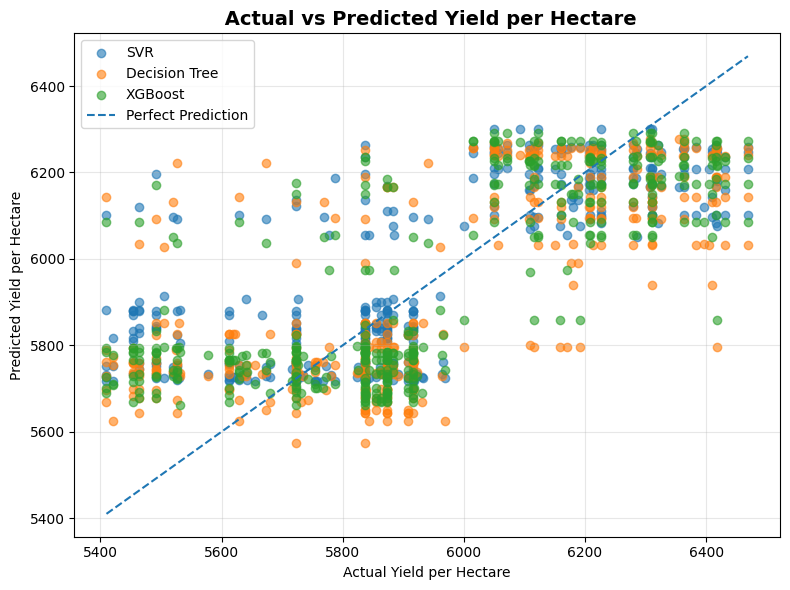

Figure 6 compares actual and predicted productivity values.
The model with points closest to the diagonal line performs better.


In [28]:
# ============================================================
# CELL 24: ACTUAL VS PREDICTED PLOT
# ============================================================
# This plot compares actual Yield_per_hectare values with
# predicted values from all three models.
#
# Points closer to the diagonal line indicate better predictions.
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(y_test, svm_predictions, alpha=0.6, label="SVR")
plt.scatter(y_test, decision_tree_predictions, alpha=0.6, label="Decision Tree")
plt.scatter(y_test, xgb_predictions, alpha=0.6, label="XGBoost")

min_value = min(y_test.min(), svm_predictions.min(), decision_tree_predictions.min(), xgb_predictions.min())
max_value = max(y_test.max(), svm_predictions.max(), decision_tree_predictions.max(), xgb_predictions.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--", label="Perfect Prediction")

plt.title(" Actual vs Predicted Yield per Hectare", fontsize=14, fontweight="bold")
plt.xlabel("Actual Yield per Hectare")
plt.ylabel("Predicted Yield per Hectare")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure 6 compares actual and predicted productivity values.")
print("The model with points closest to the diagonal line performs better.")